In [45]:
!pip install kagglehub pandas numpy matplotlib seaborn sentence-transformers faiss-cpu rank-bm25 transformers accelerate scikit-learn

In [46]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer,util
import faiss
from rank_bm25 import BM25Okapi
from transformers import pipeline

In [47]:
import kagglehub

# Download latest version
cuad_path = kagglehub.dataset_download("konradb/atticus-open-contract-dataset-aok-beta")

print("Path to dataset files:", cuad_path)

Using Colab cache for faster access to the 'atticus-open-contract-dataset-aok-beta' dataset.
Path to dataset files: /kaggle/input/atticus-open-contract-dataset-aok-beta


In [48]:
import os

cuad_path = os.path.join(cuad_path,"CUAD_v1")

print(os.listdir(cuad_path))

['CUAD_v1.json', 'master_clauses.csv', 'CUAD_v1_README.txt', 'full_contract_txt', 'full_contract_pdf', 'label_group_xlsx']


In [49]:
txt_path=os.path.join(cuad_path,"full_contract_txt")
txt_files=os.listdir(txt_path)
print("Total TXT files:",len(txt_files))

Total TXT files: 510


In [50]:
documents=[]
for file in txt_files:
    if file.endswith(".txt"):
        with open(os.path.join(txt_path,file),"r",encoding="utf-8",errors="ignore") as f:
            documents.append({"file_name":file,"text":f.read()})
contracts_df=pd.DataFrame(documents)
contracts_df.head()

,file_name,text
0,WEBHELPCOMINC_03_22_2000-EX-10.8-HOSTING AGREE...,Exhibit 10.8\n\neGAIN COMMUNICATIONS CORPORATI...
1,AlliedEsportsEntertainmentInc_20190815_8-K_EX-...,Exhibit 10.34 EVENT SPONSORSHIP AGREEMENT This...
2,LOOKSMARTLTD_07_20_2012-EX-99.(D)(I)-SPONSORSH...,SPONSORSHIP AGREEMENT THIS SPONSORSHIP AGR...
3,"BORROWMONEYCOM,INC_06_11_2020-EX-10.1-JOINT VE...",Exhibit 10.1\n\nJOINT VENTURE AGREEMENT THIS J...
4,GluMobileInc_20070319_S-1A_EX-10.09_436630_EX-...,"AMENDMENT NO. 1\n\nDated as of November 11, 20..."


In [51]:
print(contracts_df.shape)
contracts_df.info()

(510, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  510 non-null    object
 1   text       510 non-null    object
dtypes: object(2)
memory usage: 8.1+ KB


In [52]:
csv_path=os.path.join(cuad_path,"master_clauses.csv")
master_df=pd.read_csv(csv_path)
print(master_df.shape)
master_df.head()

(510, 83)


,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,...,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of ...,NaN,['This agreement shall begin upon the date of ...,...,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR T...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']",7/11/06,"['July 11 , 2006']",7/11/06,"['The term of this Agreement (the ""Initial Ter...",...,[],No,[],No,[],No,[],No,[],No
2,FulucaiProductionsLtd_20131223_10-Q_EX-10.9_83...,['CONTENT DISTRIBUTION AND LICENSE AGREEMENT'],CONTENT DISTRIBUTION AND LICENSE AGREEMENT,"['Producer', 'Fulucai Productions Ltd.', 'Conv...","CONVERGTV, INC. (“ConvergTV”); Fulucai Product...","['November 15, 2012']",11/15/12,"['November 15, 2012']",11/15/12,[],...,[],No,[],No,[],No,[],No,[],No
3,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10...,['WEBSITE CONTENT LICENSE AGREEMENT'],WEBSITE CONTENT LICENSE AGREEMENT,"['PSiTech Corporation', 'Licensor', 'Licensee'...","PSiTech Corporation (""Licensor""); Empirical Ve...","['Feb 10, 2014']",2/10/14,"['Feb 10, 2014']",2/10/14,['The initial term of this Agreement commences...,...,[],No,[],No,[],No,[],No,[],No
4,IdeanomicsInc_20160330_10-K_EX-10.26_9512211_E...,['CONTENT LICENSE AGREEMENT'],CONTENT LICENSE AGREEMENT,"['YOU ON DEMAND HOLDINGS, INC.', 'Licensor', '...",Beijing Sun Seven Stars Culture Development Li...,"['December 21, 2015']",12/21/15,"['December 21, 2015']",12/21/15,"['The Term of this Agreement (the ""Term"") shal...",...,[],No,[],No,[],No,[],No,[],No


In [53]:
json_path=os.path.join(cuad_path,"CUAD_v1.json")
with open(json_path,"r") as f:
    cuad_json=json.load(f)
print(cuad_json.keys())

dict_keys(['version', 'data'])


In [54]:
contracts_df["word_count"]=contracts_df["text"].apply(lambda x:len(x.split()))
contracts_df["word_count"].describe()

,word_count
count,510.000000
mean,7861.188235
std,8367.292546
min,109.000000
25%,2457.000000
50%,5006.000000
75%,10196.250000
max,47733.000000


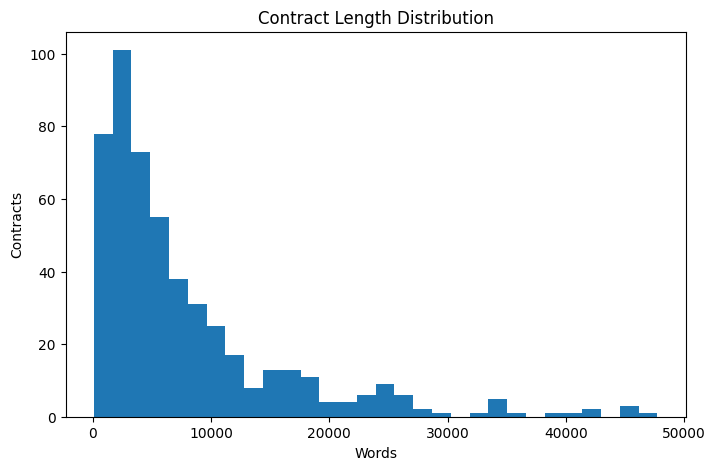

In [55]:
plt.figure(figsize=(8,5))
plt.hist(contracts_df["word_count"],bins=30)
plt.xlabel("Words")
plt.ylabel("Contracts")
plt.title("Contract Length Distribution")
plt.show()

In [56]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r"\s+"," ",text)
    text=re.sub(r"[^a-zA-Z0-9.,;: ]","",text)
    return text.strip()

In [57]:
contracts_df["clean_text"]=contracts_df["text"].apply(clean_text)
contracts_df.head()

,file_name,text,word_count,clean_text
0,WEBHELPCOMINC_03_22_2000-EX-10.8-HOSTING AGREE...,Exhibit 10.8\n\neGAIN COMMUNICATIONS CORPORATI...,2955,exhibit 10.8 egain communications corporation ...
1,AlliedEsportsEntertainmentInc_20190815_8-K_EX-...,Exhibit 10.34 EVENT SPONSORSHIP AGREEMENT This...,5852,exhibit 10.34 event sponsorship agreement this...
2,LOOKSMARTLTD_07_20_2012-EX-99.(D)(I)-SPONSORSH...,SPONSORSHIP AGREEMENT THIS SPONSORSHIP AGR...,3945,sponsorship agreement this sponsorship agreeme...
3,"BORROWMONEYCOM,INC_06_11_2020-EX-10.1-JOINT VE...",Exhibit 10.1\n\nJOINT VENTURE AGREEMENT THIS J...,3507,exhibit 10.1 joint venture agreement this join...
4,GluMobileInc_20070319_S-1A_EX-10.09_436630_EX-...,"AMENDMENT NO. 1\n\nDated as of November 11, 20...",1853,"amendment no. 1 dated as of november 11, 2005 ..."


In [58]:
train_docs,test_docs=train_test_split(contracts_df,test_size=0.2,random_state=42)
print(len(train_docs),len(test_docs))

408 102


In [59]:
def create_chunks(text,chunk_size=300,overlap=50):
    words=text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0,len(words),chunk_size-overlap)]

In [60]:
chunks=[]
for text in train_docs["clean_text"]:
    chunks.extend(create_chunks(text))
chunks_df=pd.DataFrame({"chunk_text":chunks})
print("Total chunks:",len(chunks_df))

Total chunks: 12500


In [61]:
chunks_df["chunk_length"]=chunks_df["chunk_text"].apply(lambda x:len(x.split()))
chunks_df["chunk_length"].describe()

,chunk_length
count,12500.000000
mean,294.013440
std,34.236023
min,1.000000
25%,300.000000
50%,300.000000
75%,300.000000
max,300.000000


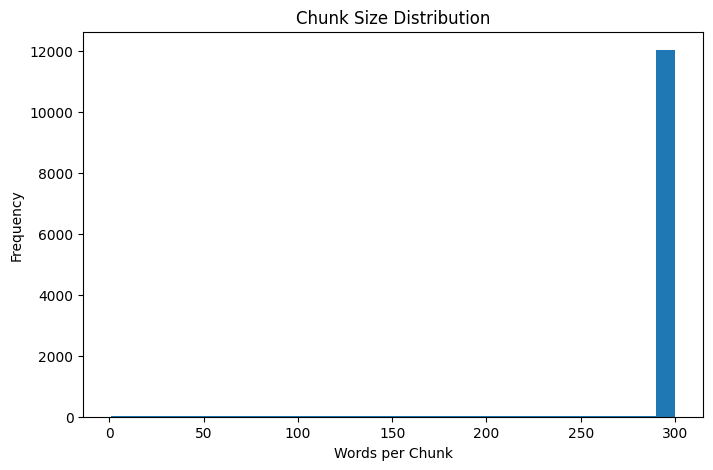

In [62]:
plt.figure(figsize=(8,5))
plt.hist(chunks_df["chunk_length"],bins=30)
plt.xlabel("Words per Chunk")
plt.ylabel("Frequency")
plt.title("Chunk Size Distribution")
plt.show()

# Install Required Libraries

In [1]:
!pip install kagglehub
!pip install sentence-transformers
!pip install faiss-cpu
!pip install rank_bm25
!pip install transformers
!pip install pandas numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 47.4 MB/s eta 0:00:00


# **Download CUAD Dataset from Kaggle**

In [2]:
import kagglehub

# Download latest CUAD dataset version

cuad_path = kagglehub.dataset_download(
    "konradb/atticus-open-contract-dataset-aok-beta"
)


print("Dataset location:")
print(cuad_path)

100%|██████████| 102M/102M [00:05<00:00, 20.2MB/s]

Extracting files...


Dataset location:
/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2


# **Explore Dataset Files**

In [3]:
import os


for root, dirs, files in os.walk(cuad_path):

    level=root.replace(
        cuad_path,
        ""
    ).count(os.sep)


    indent=" "*4*level

    print(indent + os.path.basename(root))


    for file in files[:5]:

        print(
            indent+"   ",
            file
        )

2
    CUAD_v1
        CUAD_v1_README.txt
        CUAD_v1.json
        master_clauses.csv
        full_contract_pdf
            Part_I
                IP
                    ArmstrongFlooringInc_20190107_8-K_EX-10.2_11471795_EX-10.2_Intellectual Property Agreement.pdf
                    CerenceInc_20191002_8-K_EX-10.4_11827494_EX-10.4_Intellectual Property Agreement.pdf
                    GarrettMotionInc_20181001_8-K_EX-2.4_11364532_EX-2.4_Intellectual Property Agreement.pdf
                    RareElementResourcesLtd_20171019_SC 13D_EX-99.4_10897534_EX-99.4_Intellectual Property Agreement.pdf
                Promotion
                    DovaPharmaceuticalsInc_20181108_10-Q_EX-10.2_11414857_EX-10.2_Promotion Agreement.pdf
                    SigaTechnologiesInc_20190603_8-K_EX-10.1_11695818_EX-10.1_Promotion Agreement.pdf
                    VnueInc_20150914_8-K_EX-10.1_9259571_EX-10.1_Promotion Agreement.pdf
                    ExactSciencesCorp_20180822_8-K_EX-10.1_11331629_EX-10.

# **Set Dataset Paths**

In [4]:
import os


cuad_path = "/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2"


# Main folders/files

TXT_PATH = os.path.join(
    cuad_path,
    "CUAD_v1",
    "full_contract_txt"
)


JSON_PATH = os.path.join(
    cuad_path,
    "CUAD_v1",
    "CUAD_v1.json"
)


CSV_PATH = os.path.join(
    cuad_path,
    "CUAD_v1",
    "master_clauses.csv"
)


print("TXT path:")
print(TXT_PATH)


print("\nJSON path:")
print(JSON_PATH)


print("\nCSV path:")
print(CSV_PATH)

TXT path:
/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2/CUAD_v1/full_contract_txt

JSON path:
/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2/CUAD_v1/CUAD_v1.json

CSV path:
/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2/CUAD_v1/master_clauses.csv


# **Check TXT Contracts**

In [5]:
import glob


txt_files = glob.glob(
    TXT_PATH + "/*.txt"
)


print(
    "Number of TXT contracts:",
    len(txt_files)
)


print(
    txt_files[:5]
)

Number of TXT contracts: 510
['/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2/CUAD_v1/full_contract_txt/HerImports_20161018_8-KA_EX-10.14_9765707_EX-10.14_Maintenance Agreement.txt', '/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2/CUAD_v1/full_contract_txt/MERCATAINC_03_09_2000-EX-10.21-SPONSORSHIP AGREEMENT.txt', '/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2/CUAD_v1/full_contract_txt/TICKETSCOMINC_06_22_1999-EX-10.22-SPONSORSHIP AGREEMENT.txt', '/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2/CUAD_v1/full_contract_txt/PfHospitalityGroupInc_20150923_10-12G_EX-10.1_9266710_EX-10.1_Franchise Agreement1.txt', '/root/.cache/kagglehub/datasets/konradb/atticus-open-contract-dataset-aok-beta/versions/2/CUAD_v1/full_contract_txt/CORIOINC_07_20_2000-EX-10.5-LICENSE AND HOSTING AGREEMENT.txt']


# **Load Contract Documents**

In [6]:
contracts=[]


for file in txt_files:


    with open(
        file,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        text=f.read()


    contracts.append({

        "filename":
        os.path.basename(file),

        "text":
        text

    })


print(
    "Contracts loaded:",
    len(contracts)
)


print(
    contracts[0]["filename"]
)


print(
    contracts[0]["text"][:500]
)

Contracts loaded: 510
HerImports_20161018_8-KA_EX-10.14_9765707_EX-10.14_Maintenance Agreement.txt
Exhibit 10.14   SOFTWARE MAINTENANCE AGREEMENT   This Software Maintenance Agreement (the "Agreement") is entered into as of October 13, 2016, between Leader Act Ltd HK ("LEADER"), a Nevada Corporation, (hereinafter referred to as "Leader"), and EZJR, Inc. a Nevada corporation, (hereinafter referred to as "EZJR").   WHEREAS, EZJR currently owns a Customer Relationship Management ("CRM") software program as developed by LEADER; and   WHEREAS, upon the purchase of the software EZJR entered into an


# **Load CUAD JSON For Evaluation**

In [7]:
import json


with open(
    JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    cuad_json=json.load(f)


print(
    "CUAD JSON loaded"
)

CUAD JSON loaded


# **Create Evaluation Questions**

In [8]:
import pandas as pd


evaluation_data=[]


for item in cuad_json["data"]:


    for paragraph in item["paragraphs"]:


        context=paragraph["context"]


        for qa in paragraph["qas"]:


            if len(qa["answers"]) > 0:


                evaluation_data.append({

                    "question":
                    qa["question"],


                    "answer":
                    qa["answers"][0]["text"],


                    "context":
                    context

                })


evaluation_df=pd.DataFrame(
    evaluation_data
)


print(
    "Total CUAD questions:",
    len(evaluation_df)
)


evaluation_df.head()

Total CUAD questions: 6702


,question,answer,context
0,Highlight the parts (if any) of this contract ...,DISTRIBUTOR AGREEMENT,EXHIBIT 10.6\n\n ...
1,Highlight the parts (if any) of this contract ...,Distributor,EXHIBIT 10.6\n\n ...
2,Highlight the parts (if any) of this contract ...,"7th day of September, 1999.",EXHIBIT 10.6\n\n ...
3,Highlight the parts (if any) of this contract ...,The term of this Agreement shall be ten (10)...,EXHIBIT 10.6\n\n ...
4,Highlight the parts (if any) of this contract ...,The term of this Agreement shall be ten (10)...,EXHIBIT 10.6\n\n ...


# **Create Evaluation Sample**

In [9]:
evaluation_df = evaluation_df.sample(
    n=1000,
    random_state=42
)


evaluation_df.reset_index(
    drop=True,
    inplace=True
)


print(
    "Evaluation size:",
    len(evaluation_df)
)

Evaluation size: 1000


# **Preprocess TXT Contracts**

In [10]:
import re


def clean_text(text):

    text=text.lower()


    text=re.sub(
        r"\s+",
        " ",
        text
    )


    return text.strip()



for item in contracts:

    item["clean_text"]=clean_text(
        item["text"]
    )


print(
    contracts[0]["clean_text"][:300]
)

exhibit 10.14 software maintenance agreement this software maintenance agreement (the "agreement") is entered into as of october 13, 2016, between leader act ltd hk ("leader"), a nevada corporation, (hereinafter referred to as "leader"), and ezjr, inc. a nevada corporation, (hereinafter referred to 


# **Chunk Contracts**

In [11]:
def chunk_text(
    text,
    chunk_size=300,
    overlap=50
):

    words=text.split()

    chunks=[]

    start=0


    while start < len(words):

        end=start+chunk_size


        chunk=" ".join(
            words[start:end]
        )


        chunks.append(chunk)


        start=end-overlap


    return chunks

In [12]:
chunks=[]


for contract in contracts:


    contract_chunks=chunk_text(
        contract["clean_text"]
    )


    chunks.extend(
        contract_chunks
    )


print(
    "Total chunks:",
    len(chunks)
)

Total chunks: 16282


# **Generate Sentence Transformer Embeddings**

In [13]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedding_model=SentenceTransformer("all-MiniLM-L6-v2")

chunk_embeddings=embedding_model.encode(chunks,normalize_embeddings=True,show_progress_bar=True)

chunk_embeddings=np.array(chunk_embeddings)

print("Embedding shape:",chunk_embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/509 [00:00<?, ?it/s]

Embedding shape: (16282, 384)


# **Create FAISS Vector Database**

In [14]:
import faiss

embedding_dimension=chunk_embeddings.shape[1]

faiss_index=faiss.IndexFlatIP(embedding_dimension)

faiss_index.add(chunk_embeddings)

print("FAISS index created")
print("Number of vectors:",faiss_index.ntotal)

FAISS index created
Number of vectors: 16282


# **Create BM25 Keyword Retrieval Database**

In [15]:
from rank_bm25 import BM25Okapi

tokenized_chunks=[chunk.lower().split() for chunk in chunks]

bm25_index=BM25Okapi(tokenized_chunks)

print("BM25 index created")

BM25 index created


# **Create BM25 Retrieval Function**

In [16]:
def bm25_search(query,k=5):
    query_tokens=query.lower().split()
    scores=bm25_index.get_scores(query_tokens)
    top_indexes=np.argsort(scores)[-k:][::-1]
    results=[chunks[i] for i in top_indexes]
    return results

# **Create FAISS Semantic Retrieval Function**

In [17]:
def faiss_search(query,k=5):
    query_embedding=embedding_model.encode([query],normalize_embeddings=True)
    query_embedding=np.array(query_embedding)
    scores,indexes=faiss_index.search(query_embedding,k)
    results=[chunks[i] for i in indexes[0]]
    return results

# **Create Combined Retrieval Function**

In [18]:
def combined_search(query,k=5):
    bm25_results=bm25_search(query,k)
    faiss_results=faiss_search(query,k)
    combined=list(dict.fromkeys(bm25_results+faiss_results))
    return combined[:k]

# **Test Retrieval System**

In [20]:
test_question=evaluation_df.iloc[0]["question"]

print("Question:")
print(test_question)

Question:
Highlight the parts (if any) of this contract related to "Effective Date" that should be reviewed by a lawyer. Details: The date when the contract is effective 


# **BM25 Result**

In [21]:
bm25_results=bm25_search(test_question,5)

for i,result in enumerate(bm25_results):
    print("\nBM25 Result",i+1)
    print(result[:500])


BM25 Result 1
1 exhibit 10.17 [medical manager letterhead] technical infrastructure maintenance agreement date: march 1, 1998 contract no.: pr-4544 between client name: medical manager midwest, inc. 53702 generations drive south bend, in 46635 principle contact: tom liddell and customer name: mts, inc. 9931 corporate service drive louisville, ky 40223 principle contact: gail knopf annual fee. [ ] technical support hours maximum: [*]; if retainer $[*] support extends beyond [*] hours, support will be charged a

BM25 Result 2
provided however that such termination may be for the entirety of this schedule or only for certain parts of the research project covered by this schedule. 18. special conditions: 18.1 variety release 18.1.1 "release date" shall mean the date that ceres determines that a variety developed, tested and evaluated pursuant to the terms of this schedule is ready for release, wherein upon such decision, such variety will be formally released by iger and ceres jointly (if

# **FAISS Result**

In [22]:
faiss_results=faiss_search(test_question,5)

for i,result in enumerate(faiss_results):
    print("\nFAISS Result",i+1)
    print(result[:500])


FAISS Result 1
has been requested is omitted and marked with "[***]". an unredacted version of the document has also been furnished separately to the securities and exchange commission as required by rule 406 under the securities act of 1933, as amended. appendix b [***] [***] [***] date added [***] [***] effective date [***] [***] effective date [***] [***] effective date

FAISS Result 2
products and services, all information contained on or accessible through the partner portal, as defined hereafter, any information disclosed by any third party which the third party is obligated to treat as confidential or proprietary to one of the parties hereto, trade secrets, know-how, processes, standards, product specifications, marketing plans and techniques, cost and financial pricing figures, all client or customer information (including without limitation their names, financial informa

FAISS Result 3
information of any kind or nature submitted to metavante by customer, or received by metav

# **Combined Result**

In [23]:
combined_results=combined_search(test_question,5)

for i,result in enumerate(combined_results):
    print("\nCombined Result",i+1)
    print(result[:500])


Combined Result 1
1 exhibit 10.17 [medical manager letterhead] technical infrastructure maintenance agreement date: march 1, 1998 contract no.: pr-4544 between client name: medical manager midwest, inc. 53702 generations drive south bend, in 46635 principle contact: tom liddell and customer name: mts, inc. 9931 corporate service drive louisville, ky 40223 principle contact: gail knopf annual fee. [ ] technical support hours maximum: [*]; if retainer $[*] support extends beyond [*] hours, support will be charged a

Combined Result 2
provided however that such termination may be for the entirety of this schedule or only for certain parts of the research project covered by this schedule. 18. special conditions: 18.1 variety release 18.1.1 "release date" shall mean the date that ceres determines that a variety developed, tested and evaluated pursuant to the terms of this schedule is ready for release, wherein upon such decision, such variety will be formally released by iger and ceres joi

# **Create Ground Truth Relevance Function**

In [24]:
def check_relevance(chunk,answer):
    chunk_words=set(chunk.lower().split())
    answer_words=set(answer.lower().split())
    overlap=len(chunk_words.intersection(answer_words))
    return overlap>0

# **Precision@5**

In [25]:
def precision_at_5(results,answer):
    relevant=0
    for chunk in results[:5]:
        if check_relevance(chunk,answer):
            relevant+=1
    return relevant/5

# **Recall@5**

In [26]:
def recall_at_5(results,answer):
    for chunk in results[:5]:
        if check_relevance(chunk,answer):
            return 1
    return 0

# **MRR Calculation**

In [27]:
def calculate_mrr(results,answer):
    for rank,chunk in enumerate(results,start=1):
        if check_relevance(chunk,answer):
            return 1/rank
    return 0

# **Evaluate BM25, FAISS and Combined Retrieval**

In [28]:
from tqdm import tqdm

evaluation_results=[]

for _,row in tqdm(evaluation_df.iterrows(),total=len(evaluation_df)):
    question=row["question"]
    answer=row["answer"]
    methods={"BM25":bm25_search(question,5),"FAISS":faiss_search(question,5),"Combined":combined_search(question,5)}
    for method,retrieved_docs in methods.items():
        evaluation_results.append({"Question":question,"Method":method,"Precision@5":precision_at_5(retrieved_docs,answer),"Recall@5":recall_at_5(retrieved_docs,answer),"MRR":calculate_mrr(retrieved_docs,answer)})

retrieval_results=pd.DataFrame(evaluation_results)

retrieval_results.head()

100%|██████████| 1000/1000 [12:15<00:00,  1.36it/s]


,Question,Method,Precision@5,Recall@5,MRR
0,Highlight the parts (if any) of this contract ...,BM25,0.2,1,1.0
1,Highlight the parts (if any) of this contract ...,FAISS,0.0,0,0.0
2,Highlight the parts (if any) of this contract ...,Combined,0.2,1,1.0
3,Highlight the parts (if any) of this contract ...,BM25,1.0,1,1.0
4,Highlight the parts (if any) of this contract ...,FAISS,1.0,1,1.0


# **Final Retrieval Comparison Table**

In [29]:
retrieval_summary=retrieval_results.groupby("Method")[["Precision@5","Recall@5","MRR"]].mean()

retrieval_summary

,Precision@5,Recall@5,MRR
Method,,,
BM25,0.8366,0.879,0.8460
Combined,0.8366,0.879,0.8460
FAISS,0.8282,0.860,0.8529


# **Load FLAN-T5 Model**

In [38]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name="google/flan-t5-base"

tokenizer=AutoTokenizer.from_pretrained(model_name)

model=AutoModelForSeq2SeqLM.from_pretrained(model_name)

def generate_answer(prompt):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids
    # Using reasonable default generation parameters; these can be tuned if needed.
    outputs = model.generate(input_ids, max_new_tokens=50, num_beams=5, early_stopping=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

generator = generate_answer # Assign the function to generator

print("FLAN-T5 loaded and custom generator created")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


FLAN-T5 loaded and custom generator created


# **Create RAG Prompt Function**

In [39]:
def create_prompt(question,retrieved_chunks):

    context="\n\n".join(retrieved_chunks)

    prompt=f"""
You are a legal contract assistant.
Answer the question only using the provided contract context.

Contract Context:
{context}

Question:
{question}

Answer:
"""

    return prompt

# **Create RAG Prompt Function**

In [40]:
def create_prompt(question,retrieved_chunks):

    context="\n\n".join(retrieved_chunks)

    prompt=f"""
You are a legal contract assistant.
Answer the question only using the provided contract context.

Contract Context:
{context}

Question:
{question}

Answer:
"""

    return prompt

# **Generate Answer Using Combined Retrieval**

In [43]:
def generate_rag_answer(question):

    retrieved_chunks=combined_search(question,5)

    prompt=create_prompt(question,retrieved_chunks)

    answer=generator(prompt)

    return answer,retrieved_chunks

## Test One Question

In [44]:
test_question=evaluation_df.iloc[0]["question"]

generated_answer,retrieved_context=generate_rag_answer(test_question)

print("Question:")
print(test_question)

print("\nGenerated Answer:")
print(generated_answer)

print("\nRetrieved Evidence:")
for context in retrieved_context:
    print(context[:300])
    print("----------------")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2192 > 512). Running this sequence through the model will result in indexing errors


Question:
Highlight the parts (if any) of this contract related to "Effective Date" that should be reviewed by a lawyer. Details: The date when the contract is effective 

Generated Answer:
The date when the contract is effective

Retrieved Evidence:
1 exhibit 10.17 [medical manager letterhead] technical infrastructure maintenance agreement date: march 1, 1998 contract no.: pr-4544 between client name: medical manager midwest, inc. 53702 generations drive south bend, in 46635 principle contact: tom liddell and customer name: mts, inc. 9931 corpo
----------------
provided however that such termination may be for the entirety of this schedule or only for certain parts of the research project covered by this schedule. 18. special conditions: 18.1 variety release 18.1.1 "release date" shall mean the date that ceres determines that a variety developed, tested an
----------------
date." (e) renewal agreement not signed and received by mmmw by the "effective date" will suspend all coverage of